In [1]:
# import libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
student_data = pd.read_csv(r'C:\ml_proj\student_performance.csv')


In [3]:
# drop student_id column
student_data = student_data.drop(columns= ['student_id'])
# student_data.head()

data exploration and correlation

In [4]:
student_data.shape

(1000000, 5)

In [5]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   weekly_self_study_hours  1000000 non-null  float64
 1   attendance_percentage    1000000 non-null  float64
 2   class_participation      1000000 non-null  float64
 3   total_score              1000000 non-null  float64
 4   grade                    1000000 non-null  object 
dtypes: float64(4), object(1)
memory usage: 38.1+ MB


In [6]:
student_data.isnull().any()

weekly_self_study_hours    False
attendance_percentage      False
class_participation        False
total_score                False
grade                      False
dtype: bool

In [7]:
student_data['grade'].value_counts()

grade
A    548644
B    258174
C    141980
D     44998
F      6204
Name: count, dtype: int64

In [8]:
student_data.head(3)

,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,18.5,95.6,3.8,97.9,A
1,14.0,80.0,2.5,83.9,B
2,19.5,86.3,5.3,100.0,A


In [9]:
student_data[['attendance_percentage', 'total_score']].corr()

,attendance_percentage,total_score
attendance_percentage,1.000000,-0.001014
total_score,-0.001014,1.000000


In [10]:
student_data_NAgrade = student_data.drop(columns= ['grade'])
student_data_NAgrade.head(3)

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
0,18.5,95.6,3.8,97.9
1,14.0,80.0,2.5,83.9
2,19.5,86.3,5.3,100.0


In [11]:
student_data_2 = student_data.drop(columns= ['total_score', 'grade'])
student_data_2.head(3)

,weekly_self_study_hours,attendance_percentage,class_participation
0,18.5,95.6,3.8
1,14.0,80.0,2.5
2,19.5,86.3,5.3


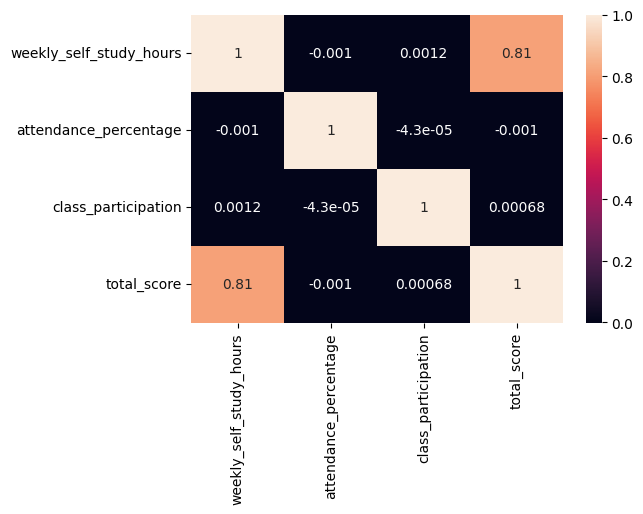

In [12]:
plt.figure(figsize=(6, 4))
sns.heatmap(data= student_data_NAgrade.corr(), annot= True)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

data splitting and target engineering

In [14]:

X = student_data.drop(columns=["total_score", "grade"])
y_reg = student_data["total_score"]

risk_grades = {"D", "F"}   # confirm this is your rule
y_clf = student_data["grade"].apply(lambda g: "At Risk" if g in risk_grades else "Safe")

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train/Test:", X_train.shape, X_test.shape)
print("Risk balance train:\n", y_clf_train.value_counts(normalize=True))

Train/Test: (800000, 3) (200000, 3)
Risk balance train:
 grade
Safe       0.948797
At Risk    0.051202
Name: proportion, dtype: float64


regression training and prediction

In [15]:
reg = RandomForestRegressor(n_estimators=100,
                            random_state=42,
                            n_jobs=-1,
                            min_samples_leaf=2
                            )

cv = KFold(n_splits=3, shuffle=True, random_state=42)

oof_pred_train = cross_val_predict(reg, X_train, y_reg_train, cv=cv, n_jobs=-1, method="predict")

reg.fit(X_train, y_reg_train)
pred_test = reg.predict(X_test)

In [16]:
print("OOF MAE:", mean_absolute_error(y_reg_train, oof_pred_train))
print("Test MAE:", mean_absolute_error(y_reg_test, pred_test))
print("Test R2 :", r2_score(y_reg_test, pred_test))

OOF MAE: 6.485267303648288
Test MAE: 6.485321634091515
Test R2 : 0.677007257663804


Adding the stacked feature (predicted_score) to X

In [17]:
X_train_aug = X_train.copy()
X_test_aug  = X_test.copy()

X_train_aug["predicted_score"] = oof_pred_train
X_test_aug["predicted_score"]  = pred_test

print(X_train_aug.shape, X_test_aug.shape)
print(X_train_aug.head())

(800000, 4) (200000, 4)
        weekly_self_study_hours  attendance_percentage  class_participation  \
736070                     22.1                  100.0                  5.5   
780767                     17.9                   74.8                  4.2   
846419                      8.7                  100.0                  5.0   
400942                     12.0                   83.2                  7.7   
385506                     11.4                   98.1                  8.5   

        predicted_score  
736070        98.419923  
780767        88.711840  
846419        78.421202  
400942        80.398965  
385506        77.694420  


Encode target to 0/1 (At Risk=1)

In [18]:
y_train_enc = (y_clf_train == "At Risk").astype(int)
y_test_enc  = (y_clf_test  == "At Risk").astype(int)

print("Train At Risk rate:", y_train_enc.mean())
print("Test  At Risk rate:", y_test_enc.mean())
print("Counts train:\n", y_train_enc.value_counts())

Train At Risk rate: 0.0512025
Test  At Risk rate: 0.0512
Counts train:
 grade
0    759038
1     40962
Name: count, dtype: int64


Build the classifier pipeline (SMOTE + RandomForest)

In [19]:
smote = SMOTE(random_state=42, sampling_strategy=0.2)

clf = RandomForestClassifier(n_estimators=100, 
                            random_state=42,
                            n_jobs=-1,
                            class_weight="balanced_subsample",
                            min_samples_leaf=2
                            )

pipe = ImbPipeline([
    ("smote", smote),
    ("clf", clf)
])

print(pipe)

Pipeline(steps=[('smote', SMOTE(random_state=42, sampling_strategy=0.2)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=2, n_jobs=-1,
                                        random_state=42))])


training and prediction for classification model

In [20]:
# This command triggers SMOTE generation and the RandomForest training
pipe.fit(X_train_aug, y_train_enc)

print("Training complete!")

Training complete!


In [21]:
y_pred = pipe.predict(X_test_aug)
y_proba = pipe.predict_proba(X_test_aug)[:, 1]  # prob of class 1 = At Risk

print("Pred counts:", pd.Series(y_pred).value_counts())
print("Proba min/mean/max:", y_proba.min(), y_proba.mean(), y_proba.max())

Pred counts: 0    188583
1     11417
Name: count, dtype: int64
Proba min/mean/max: 0.0 0.07871142494227792 1.0


Evaluate (confusion + report + ROC-AUC)

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion matrix:\n", confusion_matrix(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred, target_names=["Safe","At Risk"]))
print("ROC-AUC:", roc_auc_score(y_test_enc, y_proba))

Confusion matrix:
 [[184083   5677]
 [  4500   5740]]
              precision    recall  f1-score   support

        Safe       0.98      0.97      0.97    189760
     At Risk       0.50      0.56      0.53     10240

    accuracy                           0.95    200000
   macro avg       0.74      0.77      0.75    200000
weighted avg       0.95      0.95      0.95    200000

ROC-AUC: 0.9458030752146627


sweep thresholds and pick one with high recall

In [23]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, confusion_matrix

thresholds = [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_enc, y_pred_t).ravel()
    prec = precision_score(y_test_enc, y_pred_t, zero_division=0)
    rec  = recall_score(y_test_enc, y_pred_t)
    print(f"t={t:.2f}  recall={rec:.3f}  precision={prec:.3f}  FN={fn}  FP={fp}")

t=0.50  recall=0.561  precision=0.503  FN=4500  FP=5677
t=0.40  recall=0.648  precision=0.450  FN=3600  FP=8120
t=0.35  recall=0.695  precision=0.423  FN=3125  FP=9724
t=0.30  recall=0.737  precision=0.395  FN=2690  FP=11552
t=0.25  recall=0.780  precision=0.366  FN=2250  FP=13830
t=0.20  recall=0.818  precision=0.333  FN=1867  FP=16806
t=0.15  recall=0.858  precision=0.298  FN=1455  FP=20676
t=0.10  recall=0.899  precision=0.259  FN=1037  FP=26392


In [24]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score

t = 0.15
y_pred_015 = (y_proba >= t).astype(int)

print("Confusion:\n", confusion_matrix(y_test_enc, y_pred_015))
print("Precision(At Risk):", precision_score(y_test_enc, y_pred_015))
print("Recall(At Risk):", recall_score(y_test_enc, y_pred_015))
print(classification_report(y_test_enc, y_pred_015, target_names=["Safe","At Risk"]))

Confusion:
 [[169084  20676]
 [  1455   8785]]
Precision(At Risk): 0.2981908285530023
Recall(At Risk): 0.85791015625
              precision    recall  f1-score   support

        Safe       0.99      0.89      0.94    189760
     At Risk       0.30      0.86      0.44     10240

    accuracy                           0.89    200000
   macro avg       0.64      0.87      0.69    200000
weighted avg       0.96      0.89      0.91    200000



applying threshold to changes the decision rule after the model outputs probabilities

In [25]:
THRESHOLD = 0.15
BASE_FEATURES = ["weekly_self_study_hours", "attendance_percentage", "class_participation"]

def predict_risk_auto(new_X: pd.DataFrame, reg_model, clf_pipe, threshold=THRESHOLD):
    Xb = new_X[BASE_FEATURES].copy()
    Xb["predicted_score"] = reg_model.predict(Xb)          # stacking feature
    proba = clf_pipe.predict_proba(Xb)[:, 1]               # P(At Risk)
    pred = (proba >= threshold).astype(int)                # apply 0.15 rule
    label = np.where(pred == 1, "At Risk", "Safe")
    return pd.DataFrame({"prob_at_risk": proba, "prediction": label})

In [26]:
out = predict_risk_auto(X_test, reg, pipe, threshold=0.15)
out.head()

,prob_at_risk,prediction
0,0.00000,Safe
1,0.00000,Safe
2,0.00000,Safe
3,0.00909,Safe
4,0.00000,Safe


In [27]:
# Show the students with the HIGHEST risk probability
out_sorted = out.sort_values(by="prob_at_risk", ascending=False)
print(out_sorted.head(10))

        prob_at_risk prediction
127604      1.000000    At Risk
108353      1.000000    At Risk
113750      1.000000    At Risk
153426      1.000000    At Risk
33536       0.998340    At Risk
165060      0.998340    At Risk
118718      0.998329    At Risk
195893      0.998329    At Risk
19133       0.997947    At Risk
64067       0.997142    At Risk


In [28]:
# 1. Create a 'worst-case scenario' student
# low study hours, low attendance, low participation
bad_student = pd.DataFrame({
    'weekly_self_study_hours': [1.0],
    'attendance_percentage': [20.0],
    'class_participation': [0.5]
})

# 2. Run through your auto-function
test_result = predict_risk_auto(bad_student, reg, pipe, threshold=0.15)

print("--- Manual Test ---")
print(test_result)

--- Manual Test ---
   prob_at_risk prediction
0      0.554228    At Risk


In [29]:
import os, joblib

# 🔥 confirm where you are
print("Current working dir:", os.getcwd())

# use safe path
art_dir = os.path.join(os.getcwd(), "artifacts")
os.makedirs(art_dir, exist_ok=True)

print("Artifacts dir:", art_dir)

save_path = os.path.join(art_dir, "student_risk_artifacts.joblib")

print("Save path:", save_path)

ARTIFACTS = {
    "reg": reg,
    "clf_pipe": pipe,
    "threshold": 0.50,
    "base_features": ["weekly_self_study_hours", "attendance_percentage", "class_participation"]
}

joblib.dump(ARTIFACTS, save_path, compress=3)

print("Saved successfully!")
print("Exists:", os.path.exists(save_path))

Current working dir: c:\ml_proj
Artifacts dir: c:\ml_proj\artifacts
Save path: c:\ml_proj\artifacts\student_risk_artifacts.joblib
Saved successfully!
Exists: True


In [30]:
import os, joblib

# create the folder FIRST
os.makedirs(r"C:\temp", exist_ok=True)

save_path = r"C:\temp\student_risk_artifacts.joblib"

joblib.dump({"test": 123}, save_path)

print("Saved successfully!")
print("Exists:", os.path.exists(save_path))

Saved successfully!
Exists: True
